In [67]:
# %% 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('Orangedata.csv')
r_index = []
for i in range(len(df.index)):
    a = 'r{}'.format(i)
    r_index.append(a)

df_test = pd.read_csv('churn-bigml-80.csv')
df.index = r_index
df.index.name = 'INDEX'

In [68]:
df_test.columns = df_test.columns.str.strip().str.lower().str.replace(' ', '_')
df_test.rename(columns = {'churn': 'churned'}, inplace = True)
df_test.rename(columns = {'international_plan': 'intl_plan'}, inplace = True)
df_test.rename(columns = {'customer_service_calls': 'number_customer_service_calls'}, inplace = True)




In [69]:
df = df.dropna()
df_test = df_test.dropna()

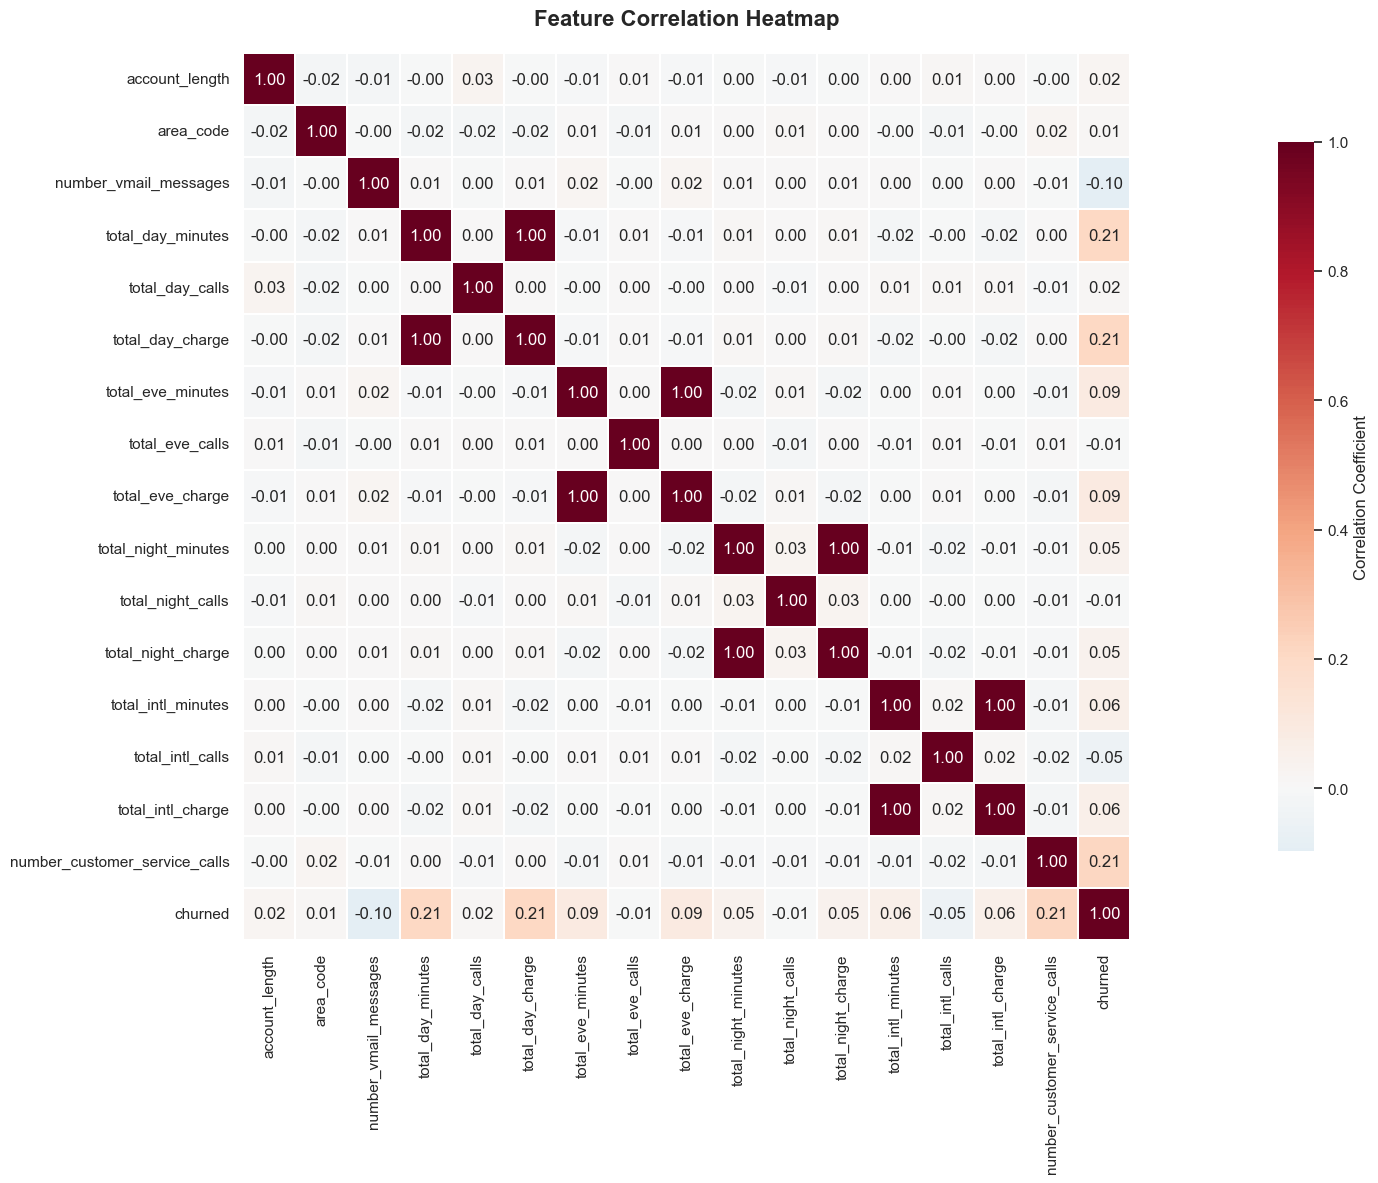

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# --- Tính ma trận tương quan ---
corr_matrix = df.corr(numeric_only=True)

# --- Cấu hình style ---
sns.set(style="white", font_scale=1)

# --- Vẽ heatmap ---
plt.figure(figsize=(30, 12))
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,            # hiển thị hệ số tương quan
    fmt=".2f",
    cmap="RdBu_r",         # bảng màu đối xứng (đỏ-xanh)
    center=0,              # đặt 0 làm trung tâm
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight="bold", pad=20)
# plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [71]:
df.drop(['state','account_length','area_code','phone_number'], axis = 1, inplace = True)
df_test.drop(['state','account_length','area_code'], axis = 1, inplace = True)



In [72]:
# Chuyển toàn bộ giá trị trong hai cột về chữ thường
df['intl_plan'] = df['intl_plan'].str.lower()
df['voice_mail_plan'] = df['voice_mail_plan'].str.lower()

df_test['intl_plan'] = df_test['intl_plan'].str.lower()
df_test['voice_mail_plan'] = df_test['voice_mail_plan'].str.lower()


In [73]:
from sklearn.preprocessing import LabelEncoder

object_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
object_cols.remove('churned')

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    df_test[col] = le.transform(df_test[col])  # chỉ transform, không fit lại

# Cuối cùng encode cột target (chỉ nên fit trên train)
target_le = LabelEncoder()
df['churned'] = target_le.fit_transform(df['churned'])
df_test['churned'] = target_le.transform(df_test['churned'])

In [74]:
from scipy import stats
import numpy as np

# Lọc các cột số, trừ 'churned' (nếu có)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('churned', errors='ignore')

# Tính Z-score cho toàn bộ cột số
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Giữ các hàng có Z-score < 3 ở **tất cả các cột**
df = df[(z_scores < 3).all(axis=1)]

#--------- Tập test ------------------
numeric_cols = df_test.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('churned', errors='ignore')

# Tính Z-score cho toàn bộ cột số
z_scores = np.abs(stats.zscore(df_test[numeric_cols], nan_policy='omit'))

# Giữ các hàng có Z-score < 3 ở **tất cả các cột**
df_test = df_test[(z_scores < 3).all(axis=1)]





In [75]:
X_train= df.drop('churned',axis =1)
y_train = df['churned']


X_test = df_test.drop('churned',axis =1)
y_test = df_test['churned']

In [76]:
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

# # X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size =0.2, random_state =99)

# test_size_dict = {
#     0: 300,   # lấy 300 mẫu lớp 0
#     1: 100    # lấy 500 mẫu lớp 1
# }

# X_train, X_test, y_train, y_test = train_test_split_balanced_test_custom(X, Y, test_size_dict)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import BernoulliNB, CategoricalNB, ComplementNB, GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,precision_score, accuracy_score, roc_auc_score, recall_score, log_loss,confusion_matrix, ConfusionMatrixDisplay,classification_report
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import RocCurveDisplay
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours


# SMOTE sẽ tạo lớp thiểu số = lớp đa số 91 hiện đang là số rất gần để mô hình chính xác
# 92 cũng là con số rất tốt, hơn 91
#93 và xoá đi cái thằng StreamingTV thì dùng bộ khoảng (300,100) ra được accuracy 96.9

smote = SMOTE(sampling_strategy=0.85, random_state=99)
#enn = EditedNearestNeighbours(n_neighbors= 3, kind_sel='mode', sampling_strategy='auto')

smote_enn = SMOTEENN(smote=smote)

X_resampled, y_resampled = smote_enn.fit_resample(X_train_train,y_train)

# Giả sử X_res, y_res đã có (dữ liệu sau cân bằng)

# Chia train/test
# X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

# Khởi tạo các mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=99),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=99),
    "XGBoost": XGBClassifier(n_estimators=1000, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, gamma=1, reg_alpha=0.1, reg_lambda=0.7),
    "RDF": RandomForestClassifier(n_estimators = 500, max_leaf_nodes = 50,random_state =99,n_jobs = -1),
    "GNB": GaussianNB(),
    "DT": DecisionTreeClassifier()
    
}
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # Lấy probability (cho ROC, PR, KS)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'Brier': brier_score_loss(y_test, y_prob)
    }

    return metrics, y_prob





In [78]:
results = []
probs_balanced = {}
probs_unbalanced = {}

# ===== Balanced =====
for name, model in models.items():
    model.fit(X_resampled, y_resampled)
    scores, y_prob = evaluate_model(model, X_test, y_test)
    
    scores["Model"] = name
    results.append(scores)
    probs_balanced[name] = y_prob

# ===== Unbalanced =====
for name, model in models.items():
    model.fit(X_train_train, y_train)
    scores, y_prob = evaluate_model(model, X_test, y_test)
    
    scores["Model"] = name
    results.append(scores)
    probs_unbalanced[name] = y_prob

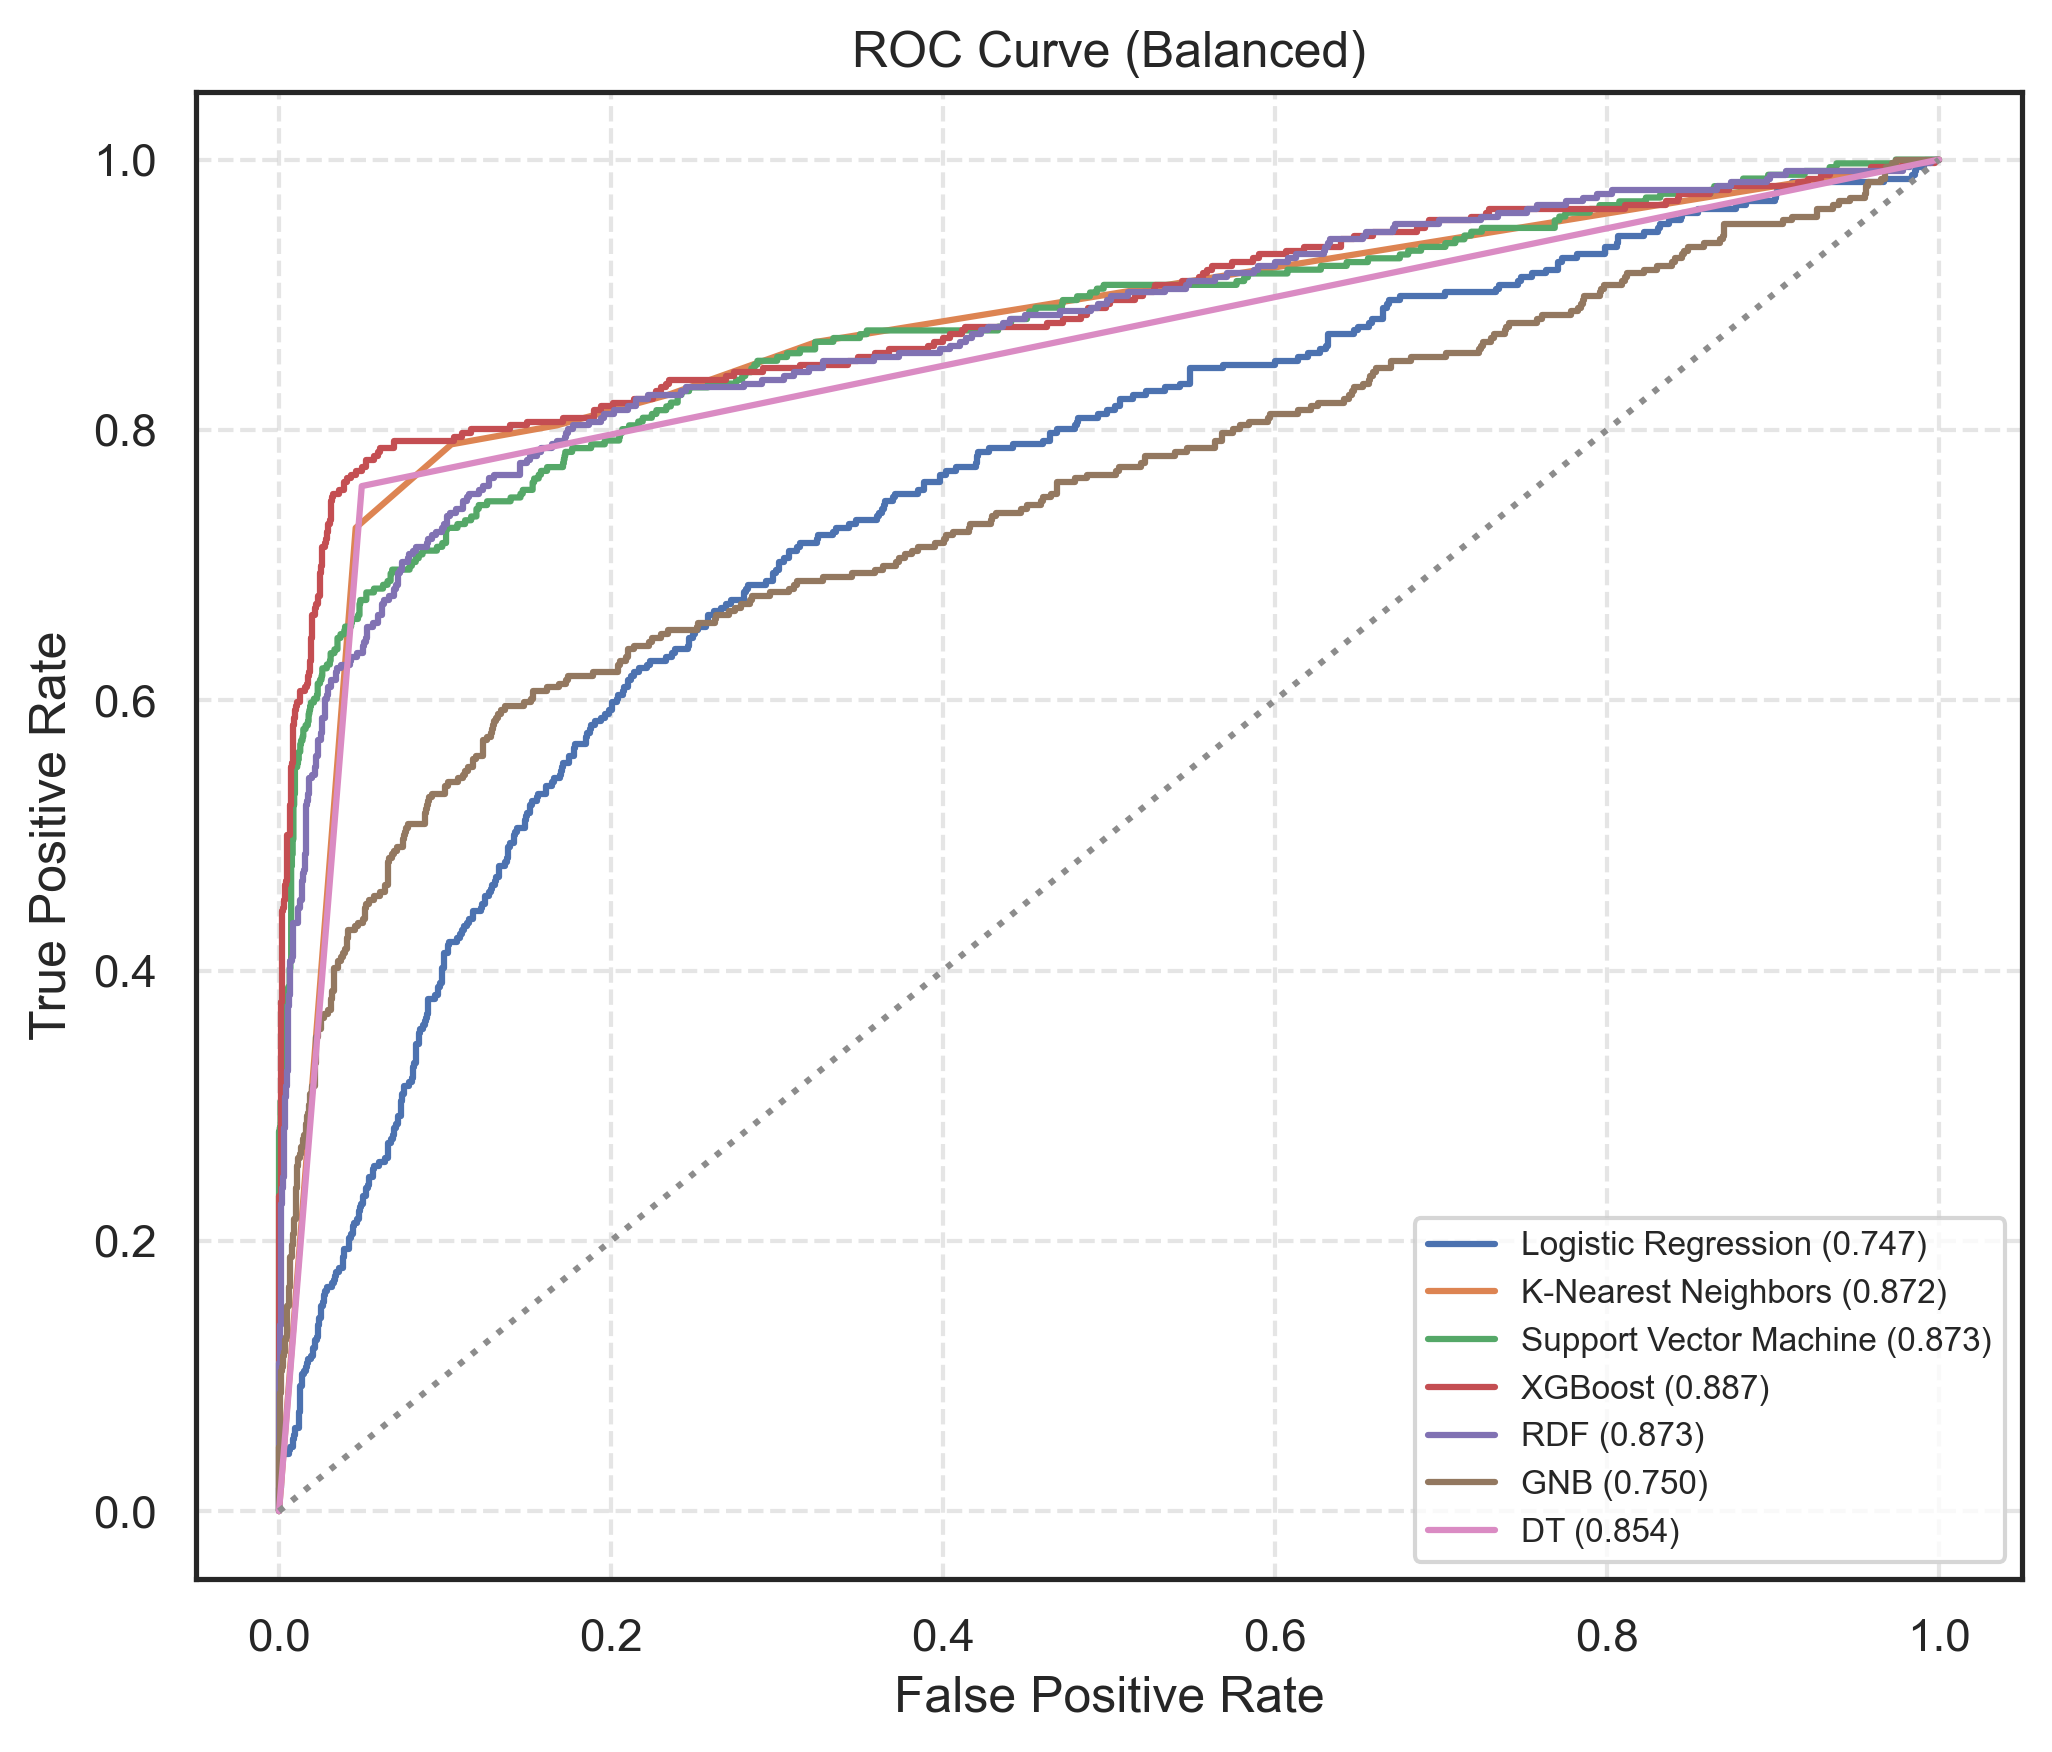

In [79]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6), dpi=300)

for name in models.keys():
    y_prob = probs_balanced[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} ({auc_score:.3f})")

plt.plot([0,1], [0,1], linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Balanced)")

plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("roc_balanced.png", dpi=300)
plt.show()

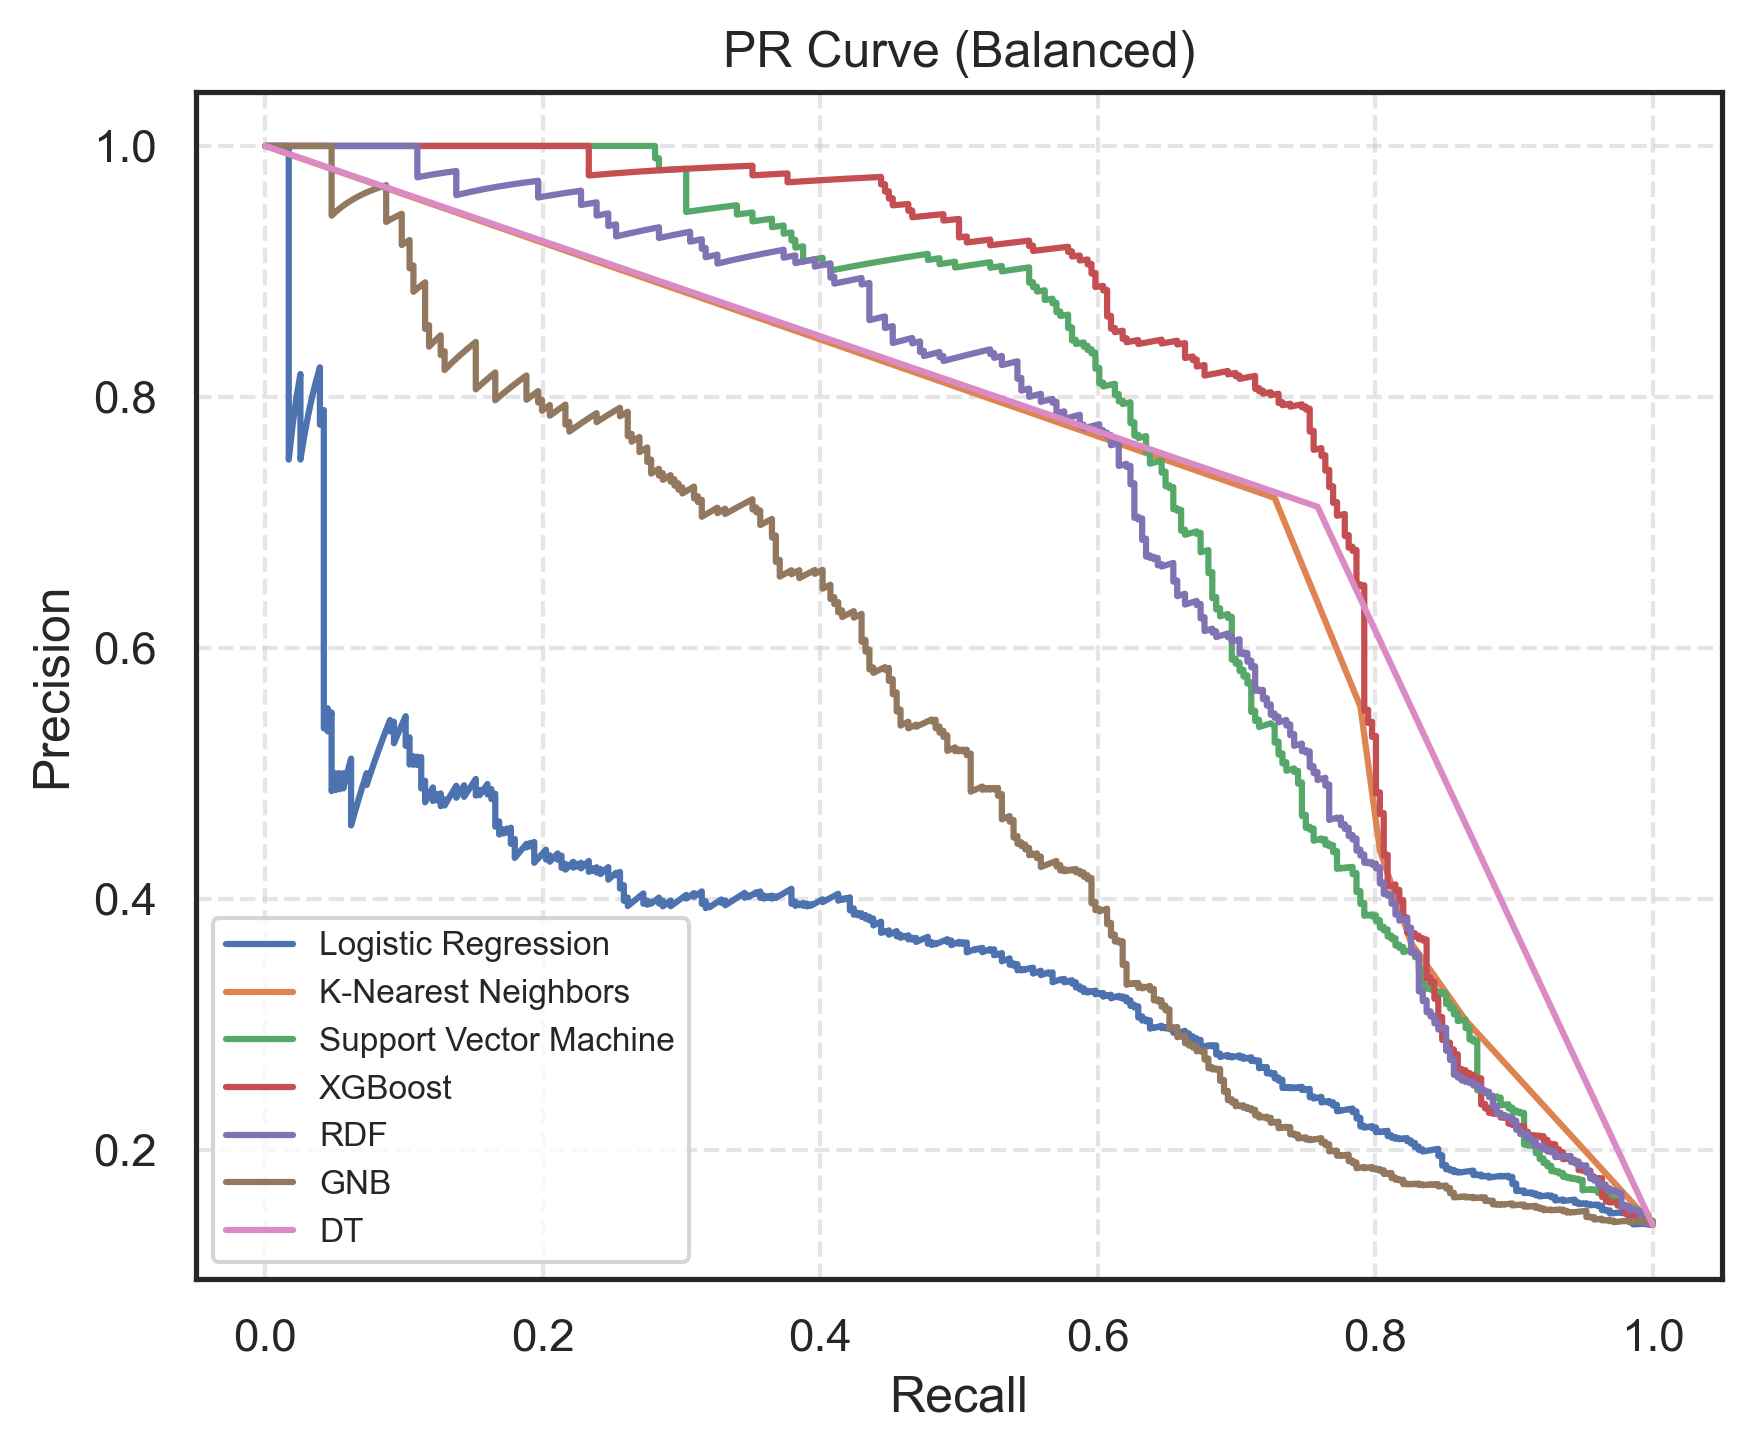

In [80]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(6,5), dpi=300)

for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, probs_balanced[name])
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (Balanced)")

plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("pr_curve.png", dpi=300)
plt.show()

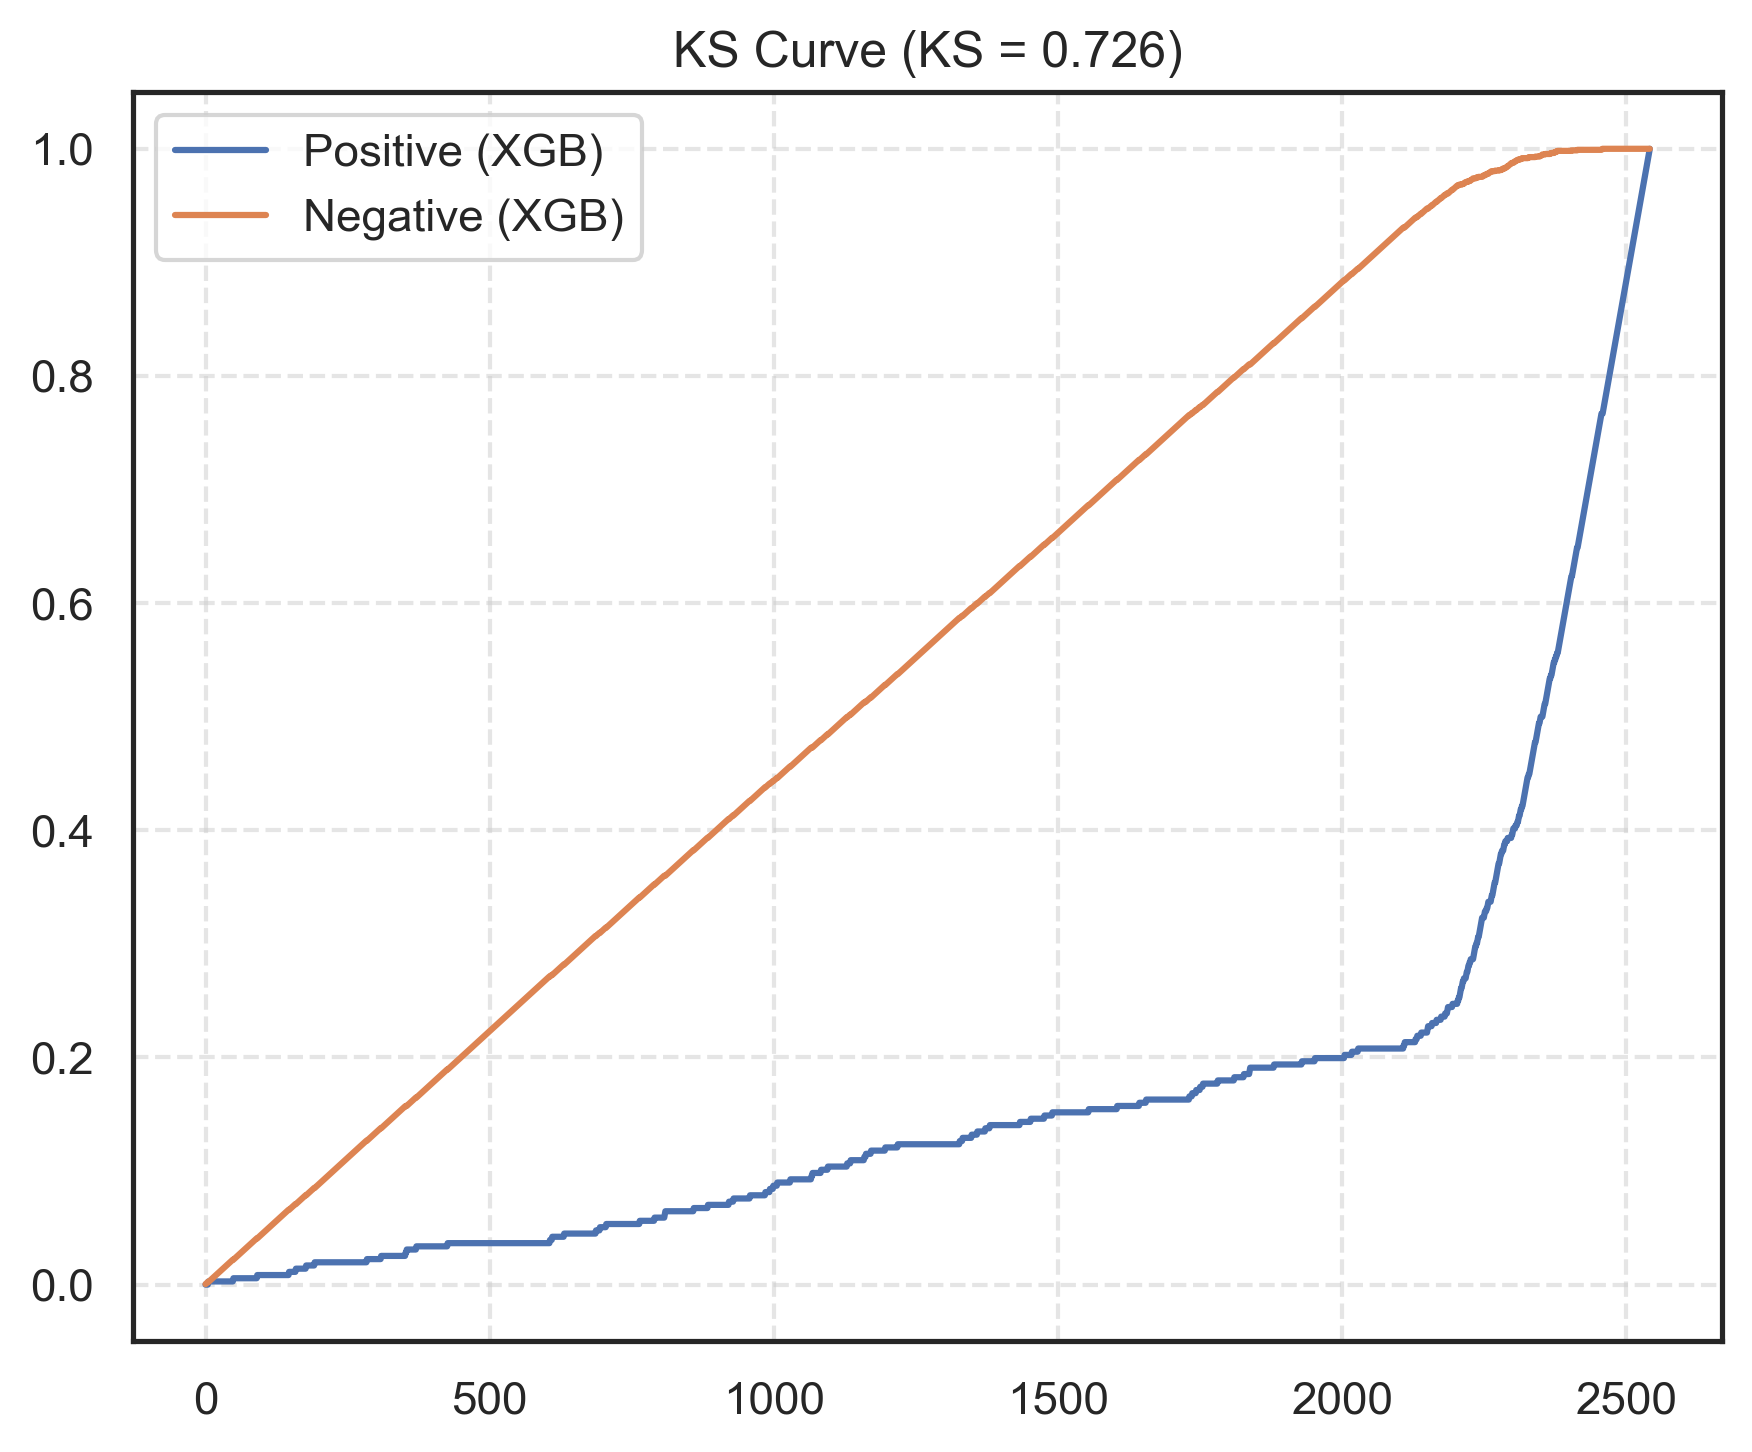

In [81]:
import numpy as np

def plot_ks(y_true, y_prob, label="Model"):
    data = np.array(list(zip(y_true, y_prob)))
    data = data[data[:,1].argsort()]

    cum_pos = np.cumsum(data[:,0]) / sum(data[:,0])
    cum_neg = np.cumsum(1 - data[:,0]) / sum(1 - data[:,0])

    ks = np.max(np.abs(cum_pos - cum_neg))

    plt.plot(cum_pos, label=f"Positive ({label})")
    plt.plot(cum_neg, label=f"Negative ({label})")

    return ks

plt.figure(figsize=(6,5), dpi=300)

ks_value = plot_ks(y_test, probs_balanced["XGBoost"], "XGB")

plt.title(f"KS Curve (KS = {ks_value:.3f})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("ks_curve.png", dpi=300)
plt.show()

In [82]:
import pandas as pd

results = []

# Train & evaluate từng model
for name, model in models.items():
    model.fit(X_resampled, y_resampled)
    scores, l= evaluate_model(model, X_test, y_test)
    scores["Model"] = name
    results.append(scores)

# Tạo DataFrame kết quả

df_results = pd.DataFrame(results)
df_results = df_results[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC","PR-AUC","Brier"]]

# In bảng kết quả
df_results

# Nếu muốn sắp xếp theo F1 giảm dần:



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.721873,0.287787,0.668539,0.402367,0.747233,0.358028,0.192698
1,K-Nearest Neighbors,0.828482,0.438650,0.803371,0.567460,0.871915,0.602762,0.127616
2,Support Vector Machine,0.888670,0.585480,0.702247,0.638570,0.873211,0.741887,0.096284
3,XGBoost,0.937057,0.814103,0.713483,0.760479,0.887285,0.792940,0.054765
4,RDF,0.903226,0.654494,0.654494,0.654494,0.872899,0.717382,0.082293
5,GNB,0.654209,0.242871,0.693820,0.359796,0.750028,0.514257,0.230055
6,DT,0.926436,0.728997,0.755618,0.742069,0.854936,0.585068,0.073564


In [84]:
for name, model in models.items():
    model.fit(X_train_train, y_train)
    scores,l = evaluate_model(model, X_test, y_test)
    scores["Model"] = name
    results.append(scores)

# Tạo DataFrame kết quả

df_results = pd.DataFrame(results)
df_results = df_results[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC","PR-AUC","Brier"]]

# In bảng kết quả
df_results

# Nếu muốn sắp xếp theo F1 giảm dần:

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.721873,0.287787,0.668539,0.402367,0.747233,0.358028,0.192698
1,K-Nearest Neighbors,0.828482,0.438650,0.803371,0.567460,0.871915,0.602762,0.127616
2,Support Vector Machine,0.888670,0.585480,0.702247,0.638570,0.873211,0.741887,0.096284
3,XGBoost,0.937057,0.814103,0.713483,0.760479,0.887285,0.792940,0.054765
4,RDF,0.903226,0.654494,0.654494,0.654494,0.872899,0.717382,0.082293
5,GNB,0.654209,0.242871,0.693820,0.359796,0.750028,0.514257,0.230055
6,DT,0.926436,0.728997,0.755618,0.742069,0.854936,0.585068,0.073564
7,Logistic Regression,0.868214,0.677966,0.112360,0.192771,0.736893,0.412173,0.103915
8,K-Nearest Neighbors,0.910700,0.984962,0.367978,0.535787,0.872719,0.666866,0.071125
9,Support Vector Machine,0.928009,0.994286,0.488764,0.655367,0.855883,0.745984,0.059118


In [85]:
df_balanced = df_results.iloc[0:7]
df_unbalanced = df_results.iloc[7:14]

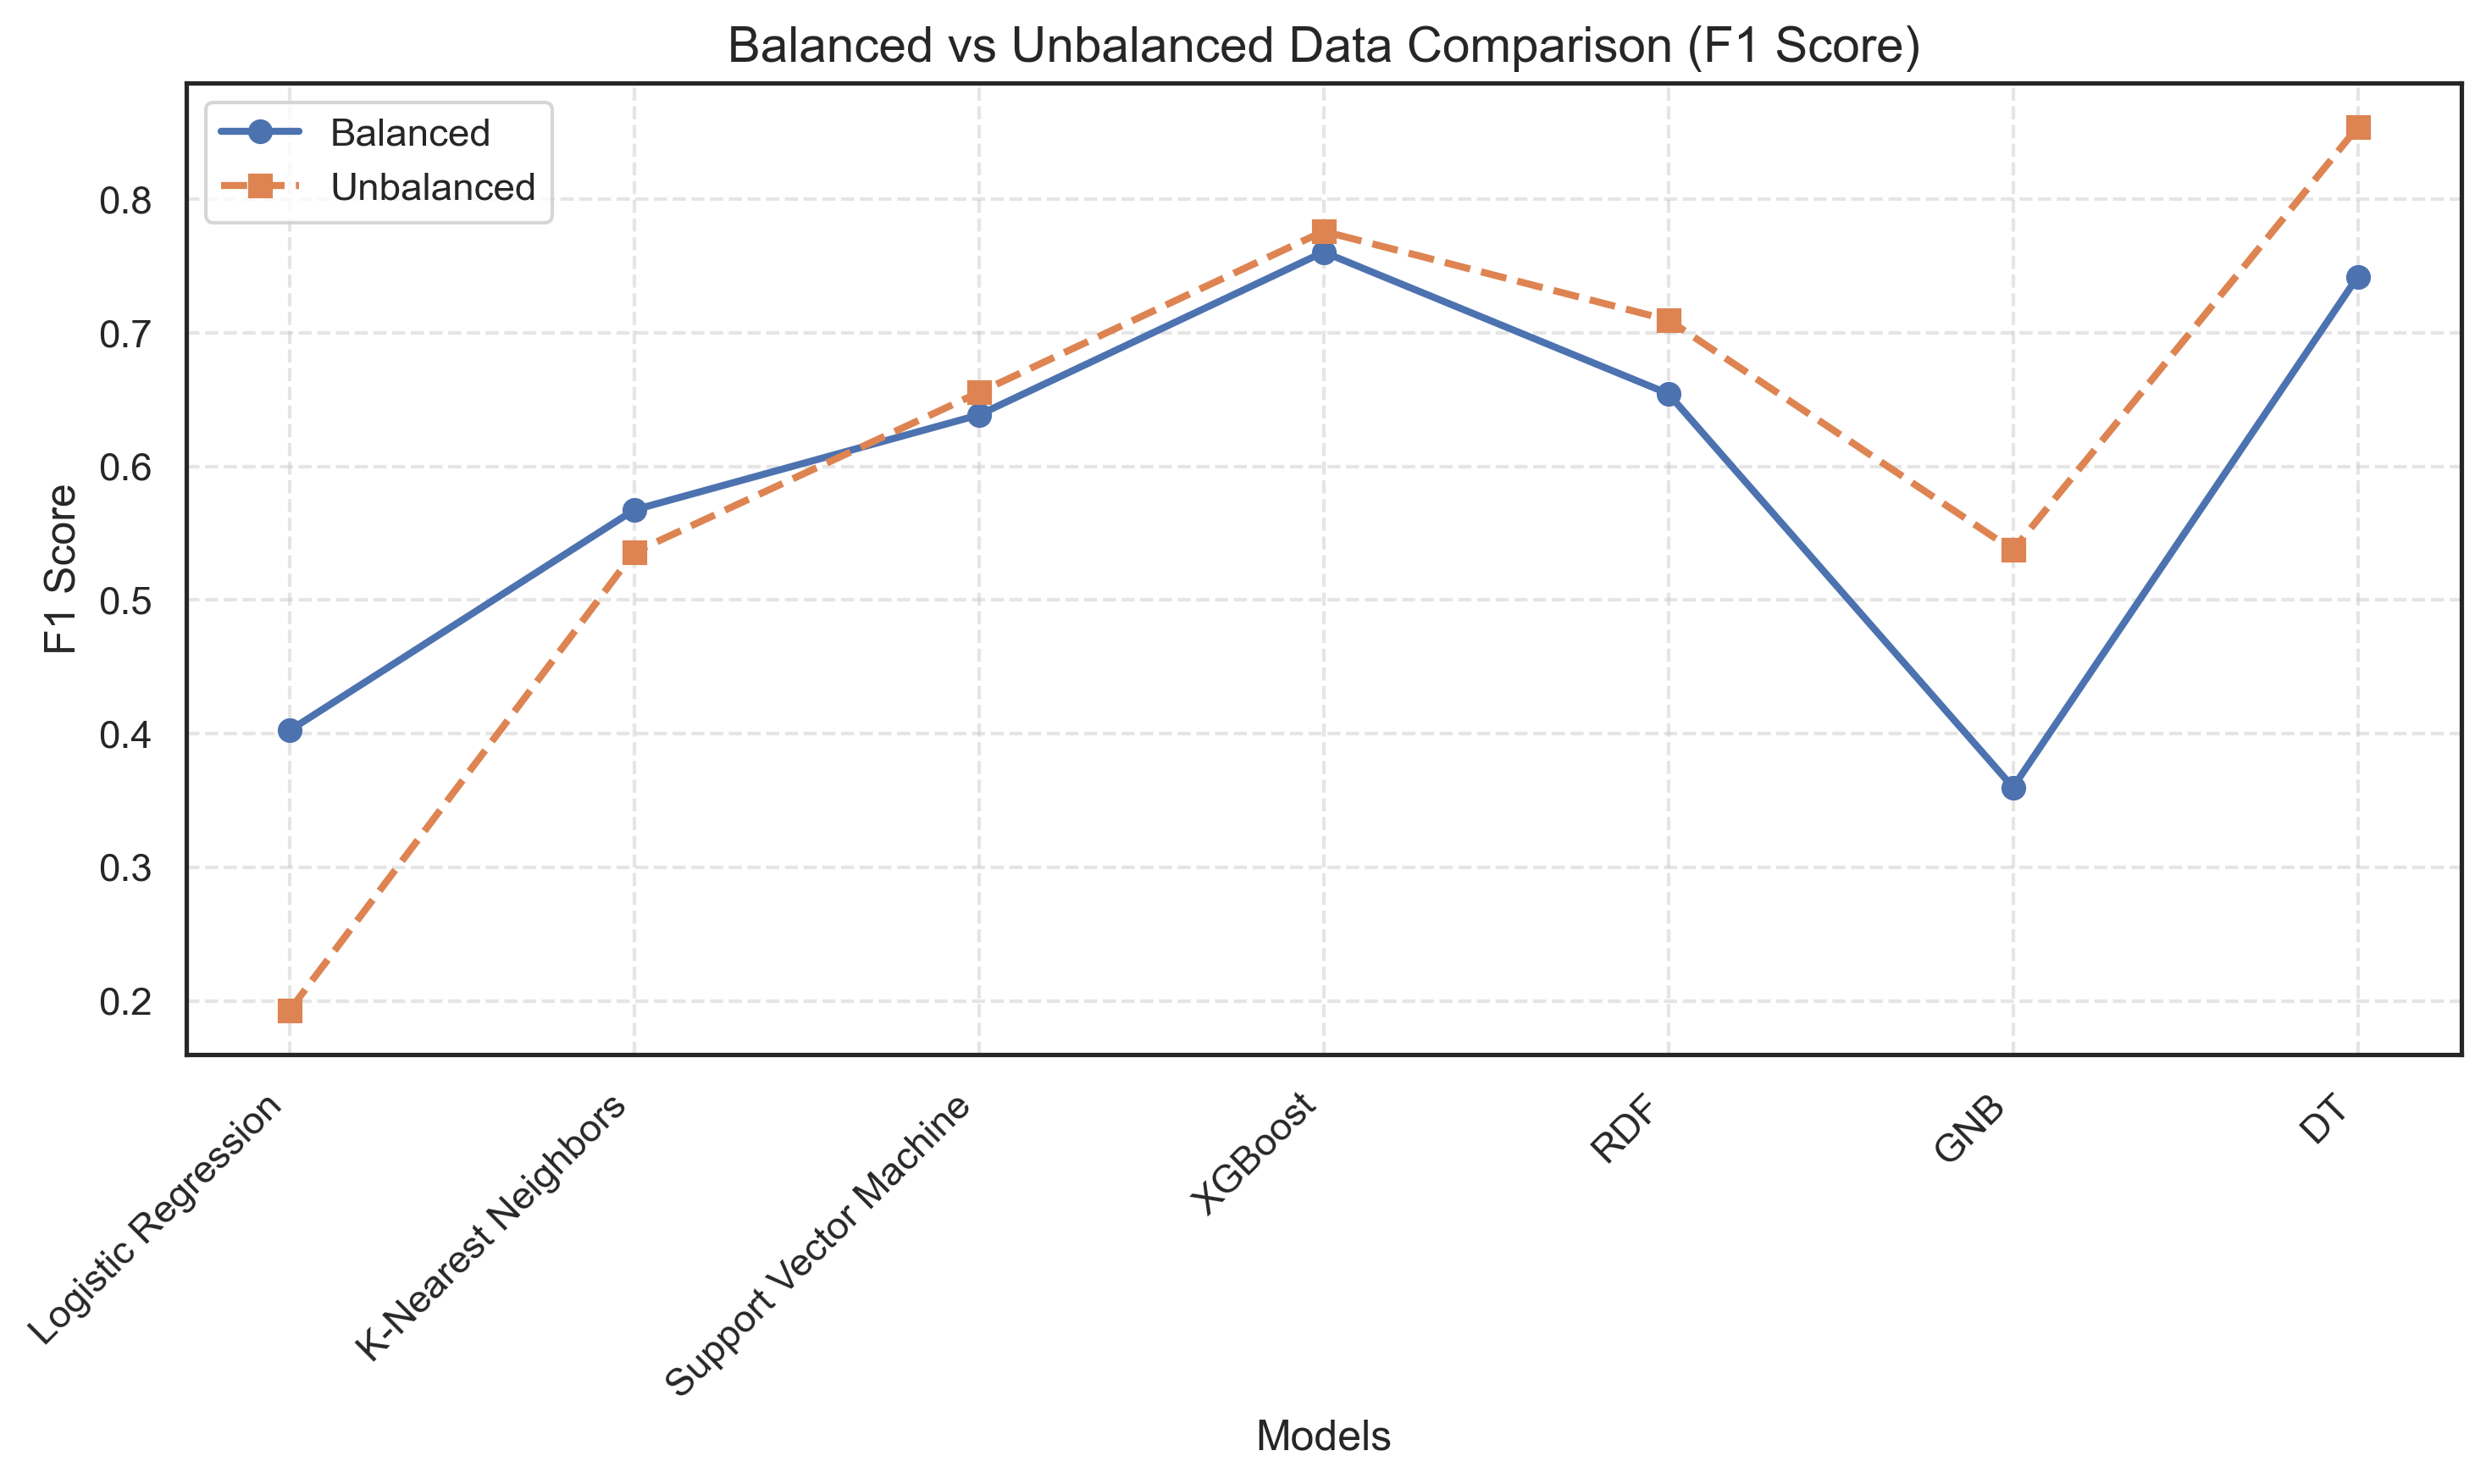

In [86]:
import matplotlib.pyplot as plt

# Reset index
df_balanced = df_results.iloc[0:7].reset_index(drop=True)
df_unbalanced = df_results.iloc[7:14].reset_index(drop=True)

models = df_balanced["Model"]

# Tạo figure DPI cao
plt.figure(figsize=(10, 6), dpi=300)

# Plot
plt.plot(models, df_balanced["F1"], marker='o', linewidth=2, label="Balanced")
plt.plot(models, df_unbalanced["F1"], marker='s', linewidth=2, linestyle='--', label="Unbalanced")

# Format
plt.xticks(rotation=45, ha='right')
plt.xlabel("Models", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.title("Balanced vs Unbalanced Data Comparison (F1 Score)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()

# Save ảnh chất lượng cao
plt.savefig("f1_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

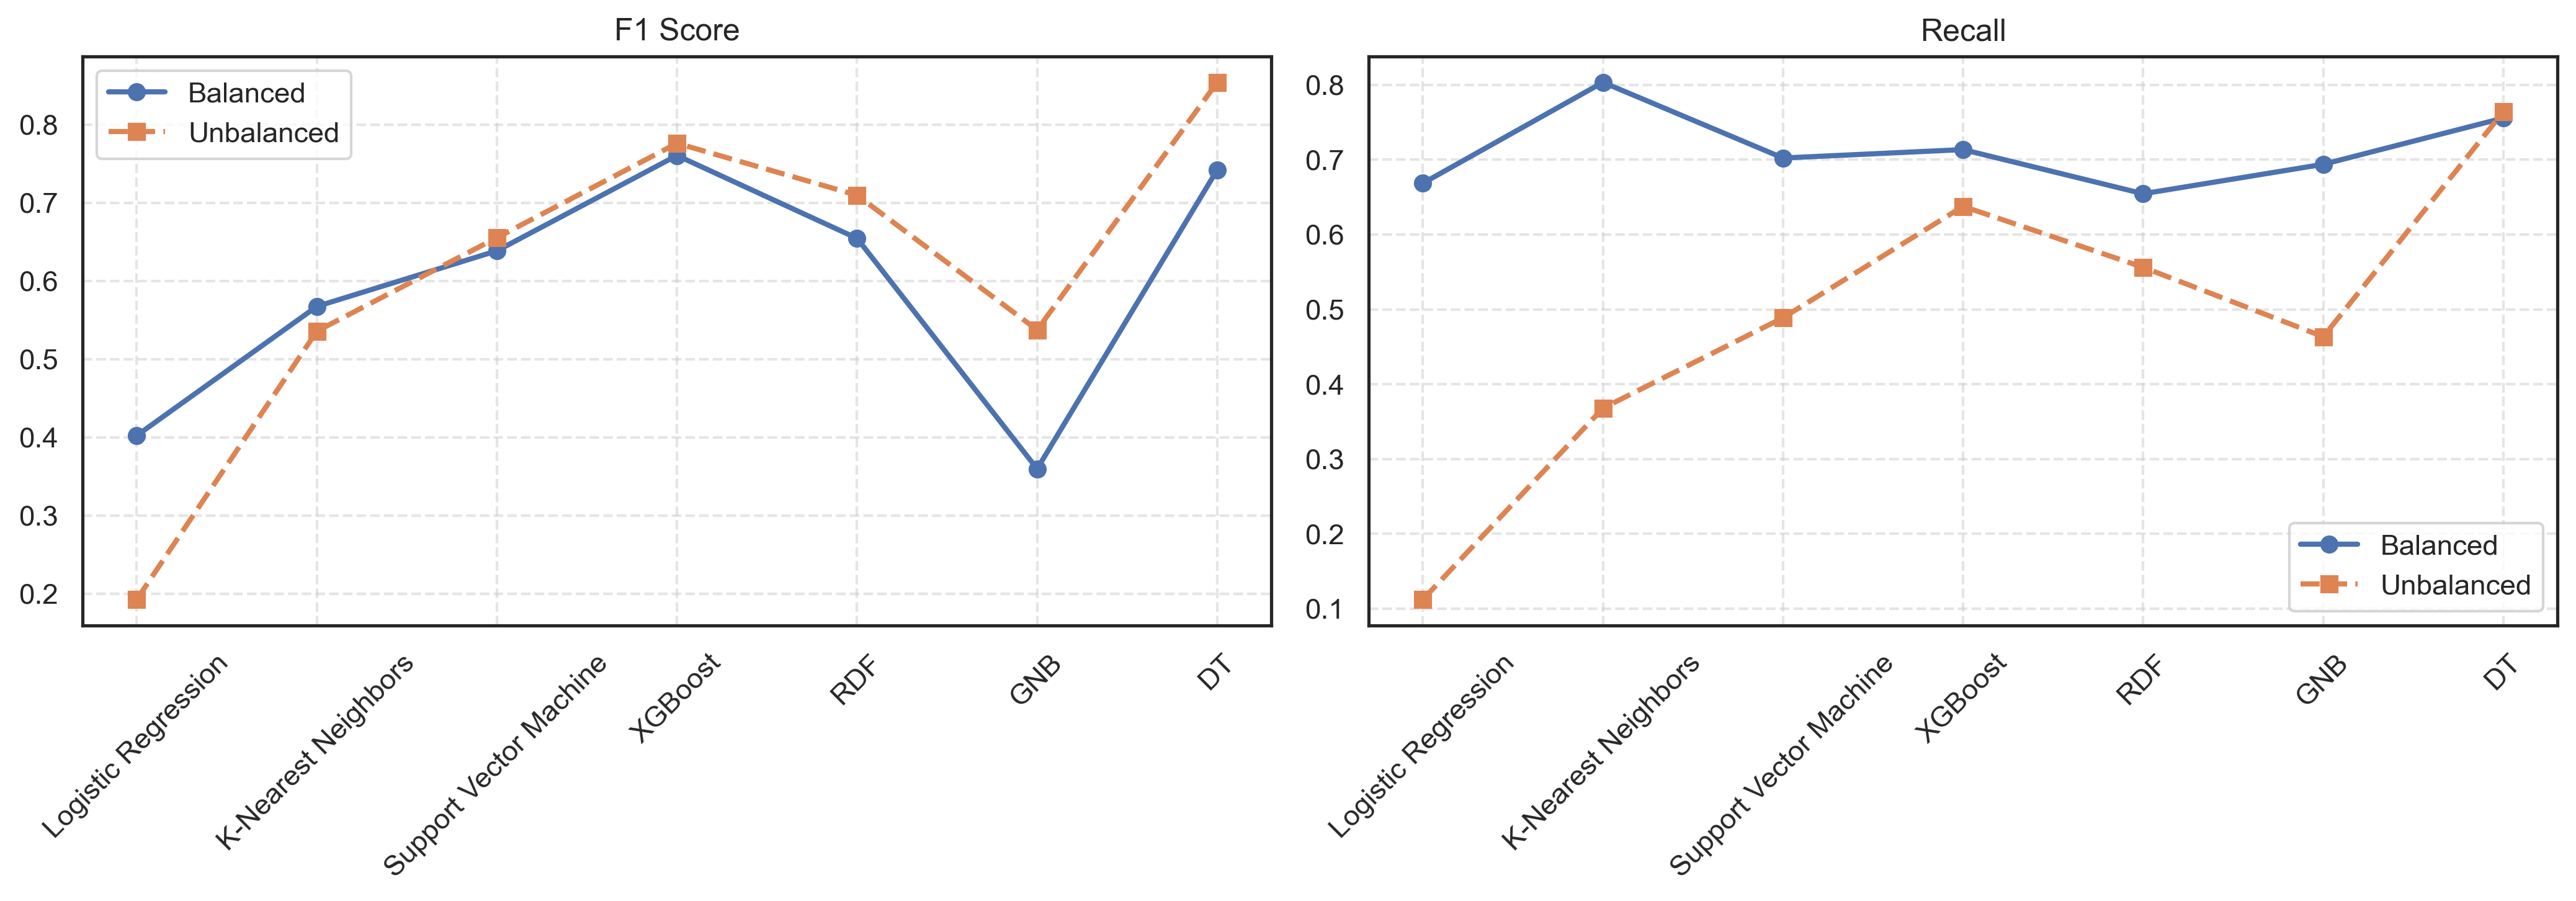

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# F1
ax[0].plot(models, df_balanced["F1"], marker='o', linewidth=2, label="Balanced")
ax[0].plot(models, df_unbalanced["F1"], marker='s', linewidth=2, linestyle='--', label="Unbalanced")
ax[0].set_title("F1 Score")
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(True, linestyle='--', alpha=0.5)

# Recall
ax[1].plot(models, df_balanced["Recall"], marker='o', linewidth=2, label="Balanced")
ax[1].plot(models, df_unbalanced["Recall"], marker='s', linewidth=2, linestyle='--', label="Unbalanced")
ax[1].set_title("Recall")
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(True, linestyle='--', alpha=0.5)

for a in ax:
    a.legend()

plt.tight_layout()
plt.savefig("comparison_multi.png", dpi=300, bbox_inches='tight')
plt.show()

In [88]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12
})

# Reset index
df_balanced = df_results.iloc[0:7].reset_index(drop=True)
df_unbalanced = df_results.iloc[7:14].reset_index(drop=True)

models = df_balanced["Model"]
x = np.arange(len(models))

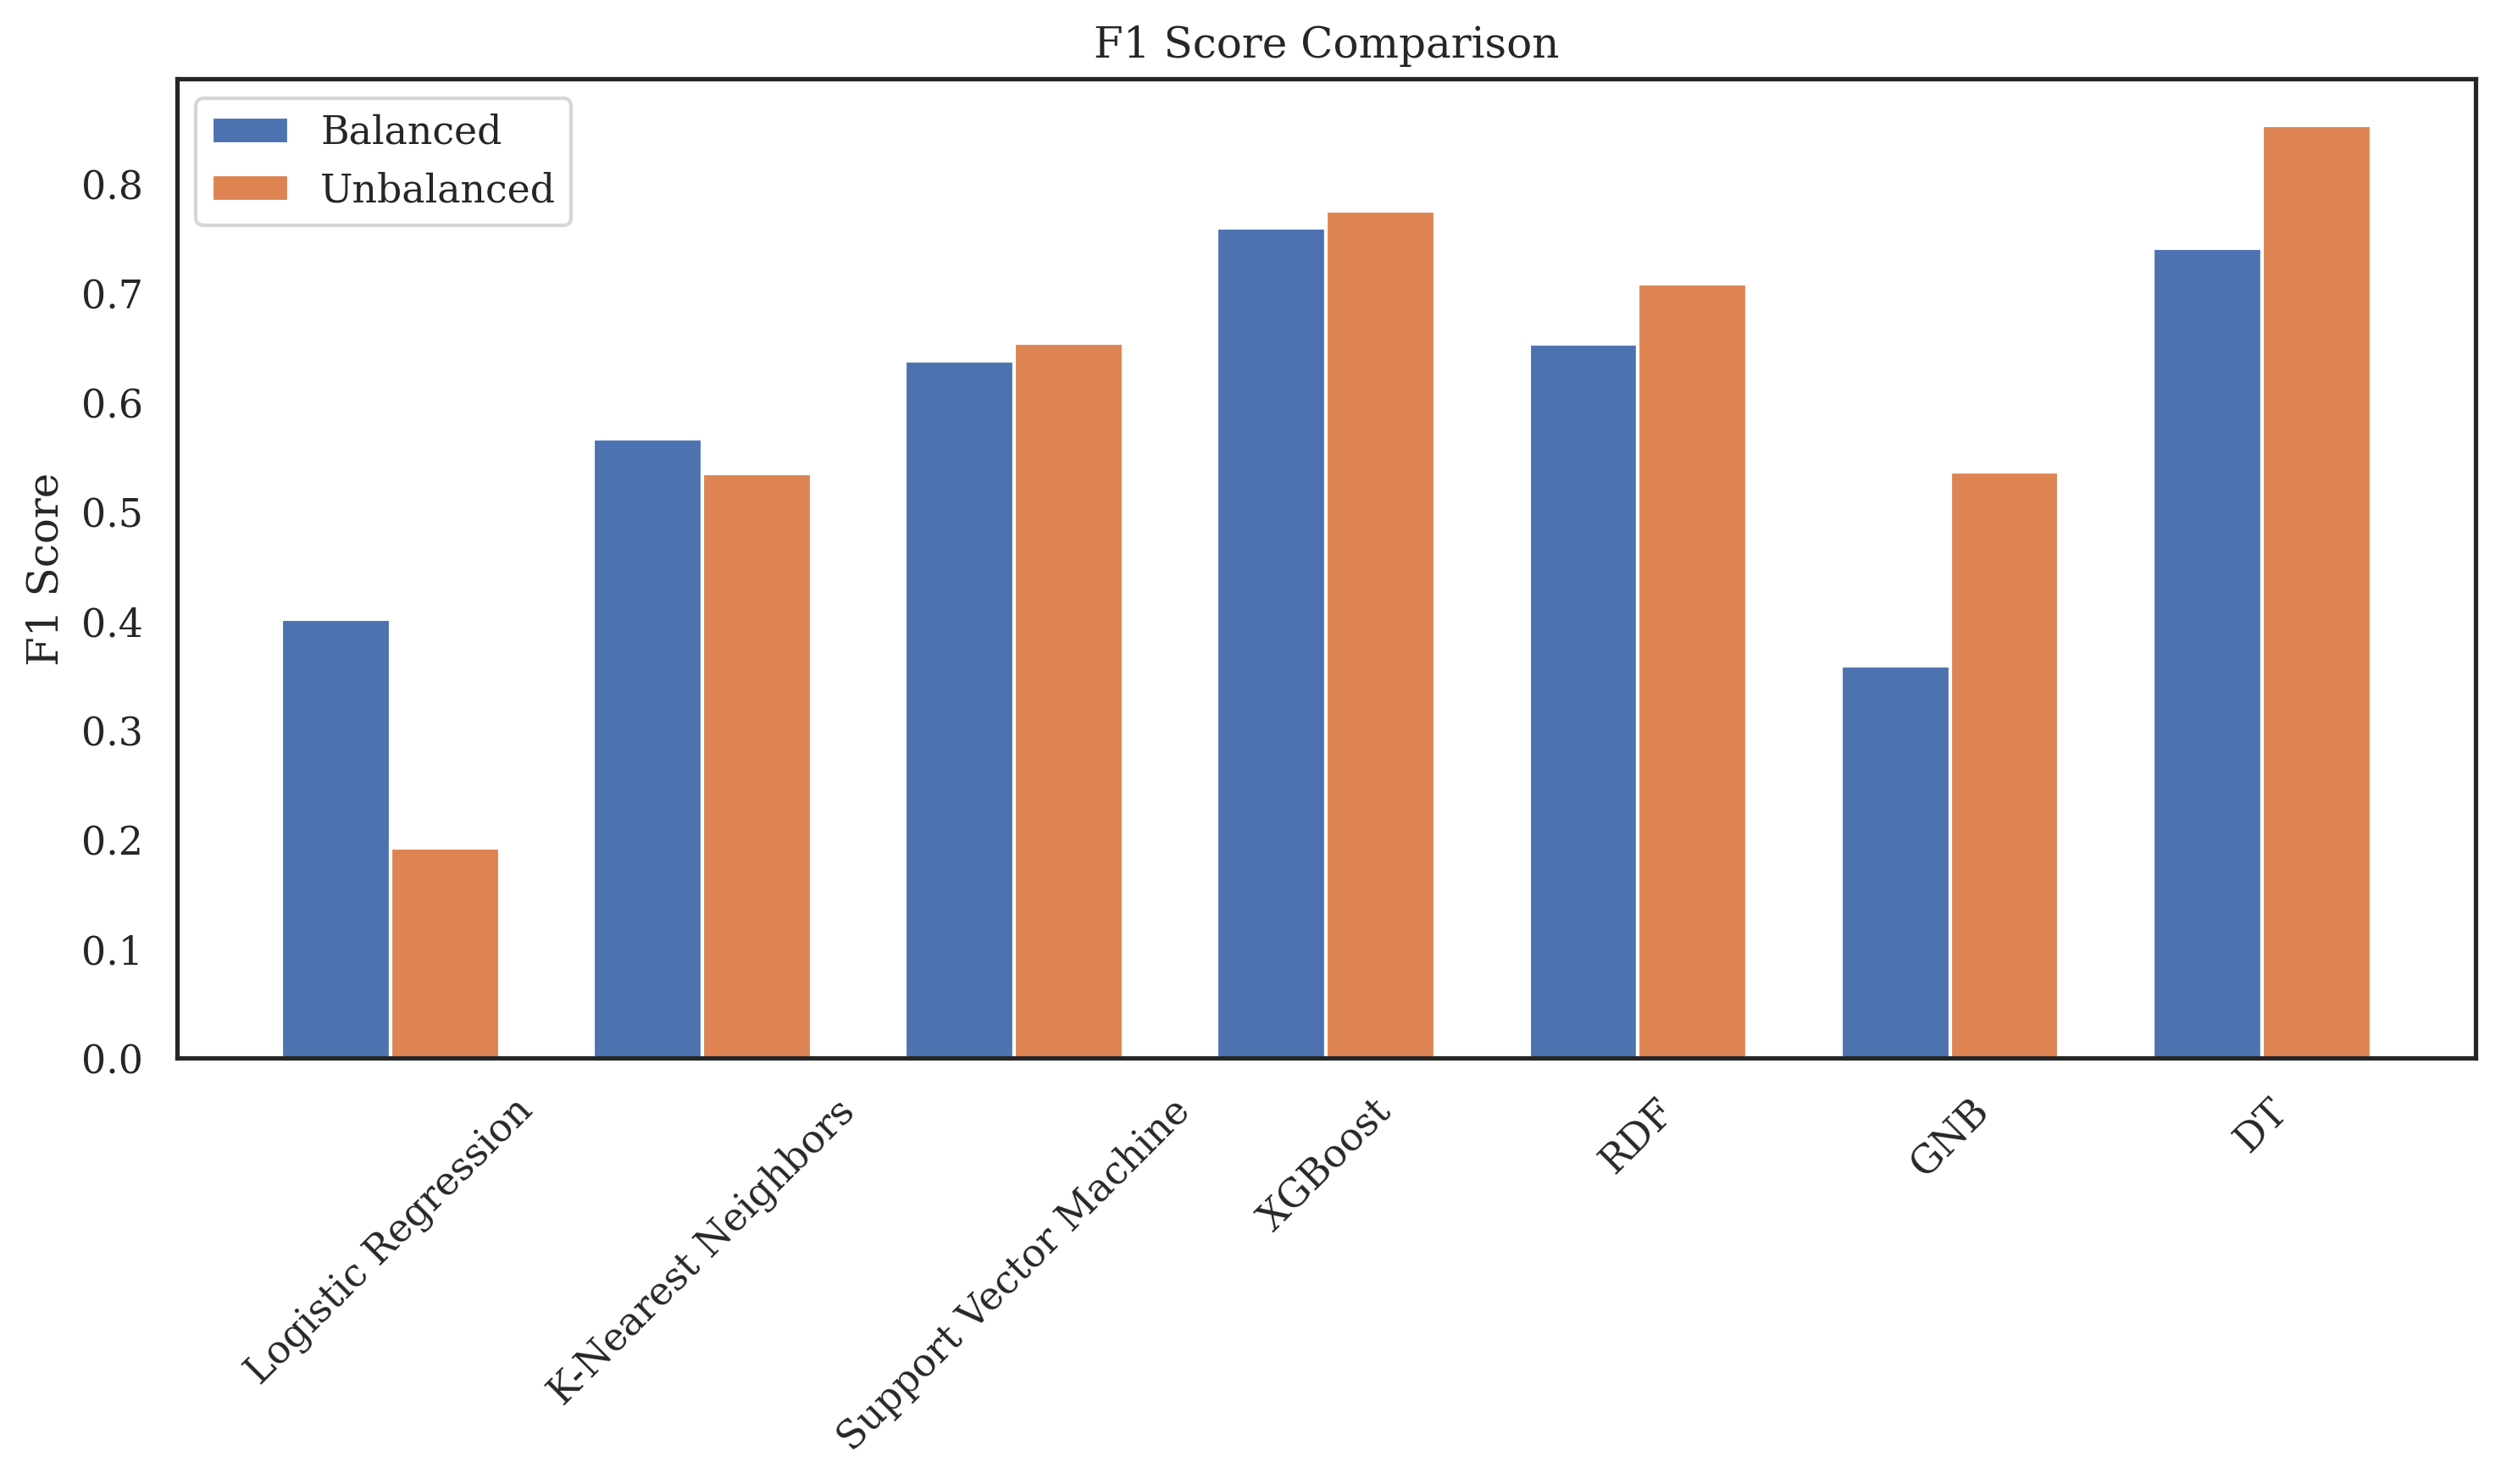

In [89]:
width = 0.35

plt.figure(figsize=(10,6), dpi=300)

plt.bar(x - width/2, df_balanced["F1"], width, label="Balanced")
plt.bar(x + width/2, df_unbalanced["F1"], width, label="Unbalanced")

plt.xticks(x, models, rotation=45)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")

plt.legend()
plt.tight_layout()
plt.savefig("bar_f1.png", dpi=300)
plt.show()

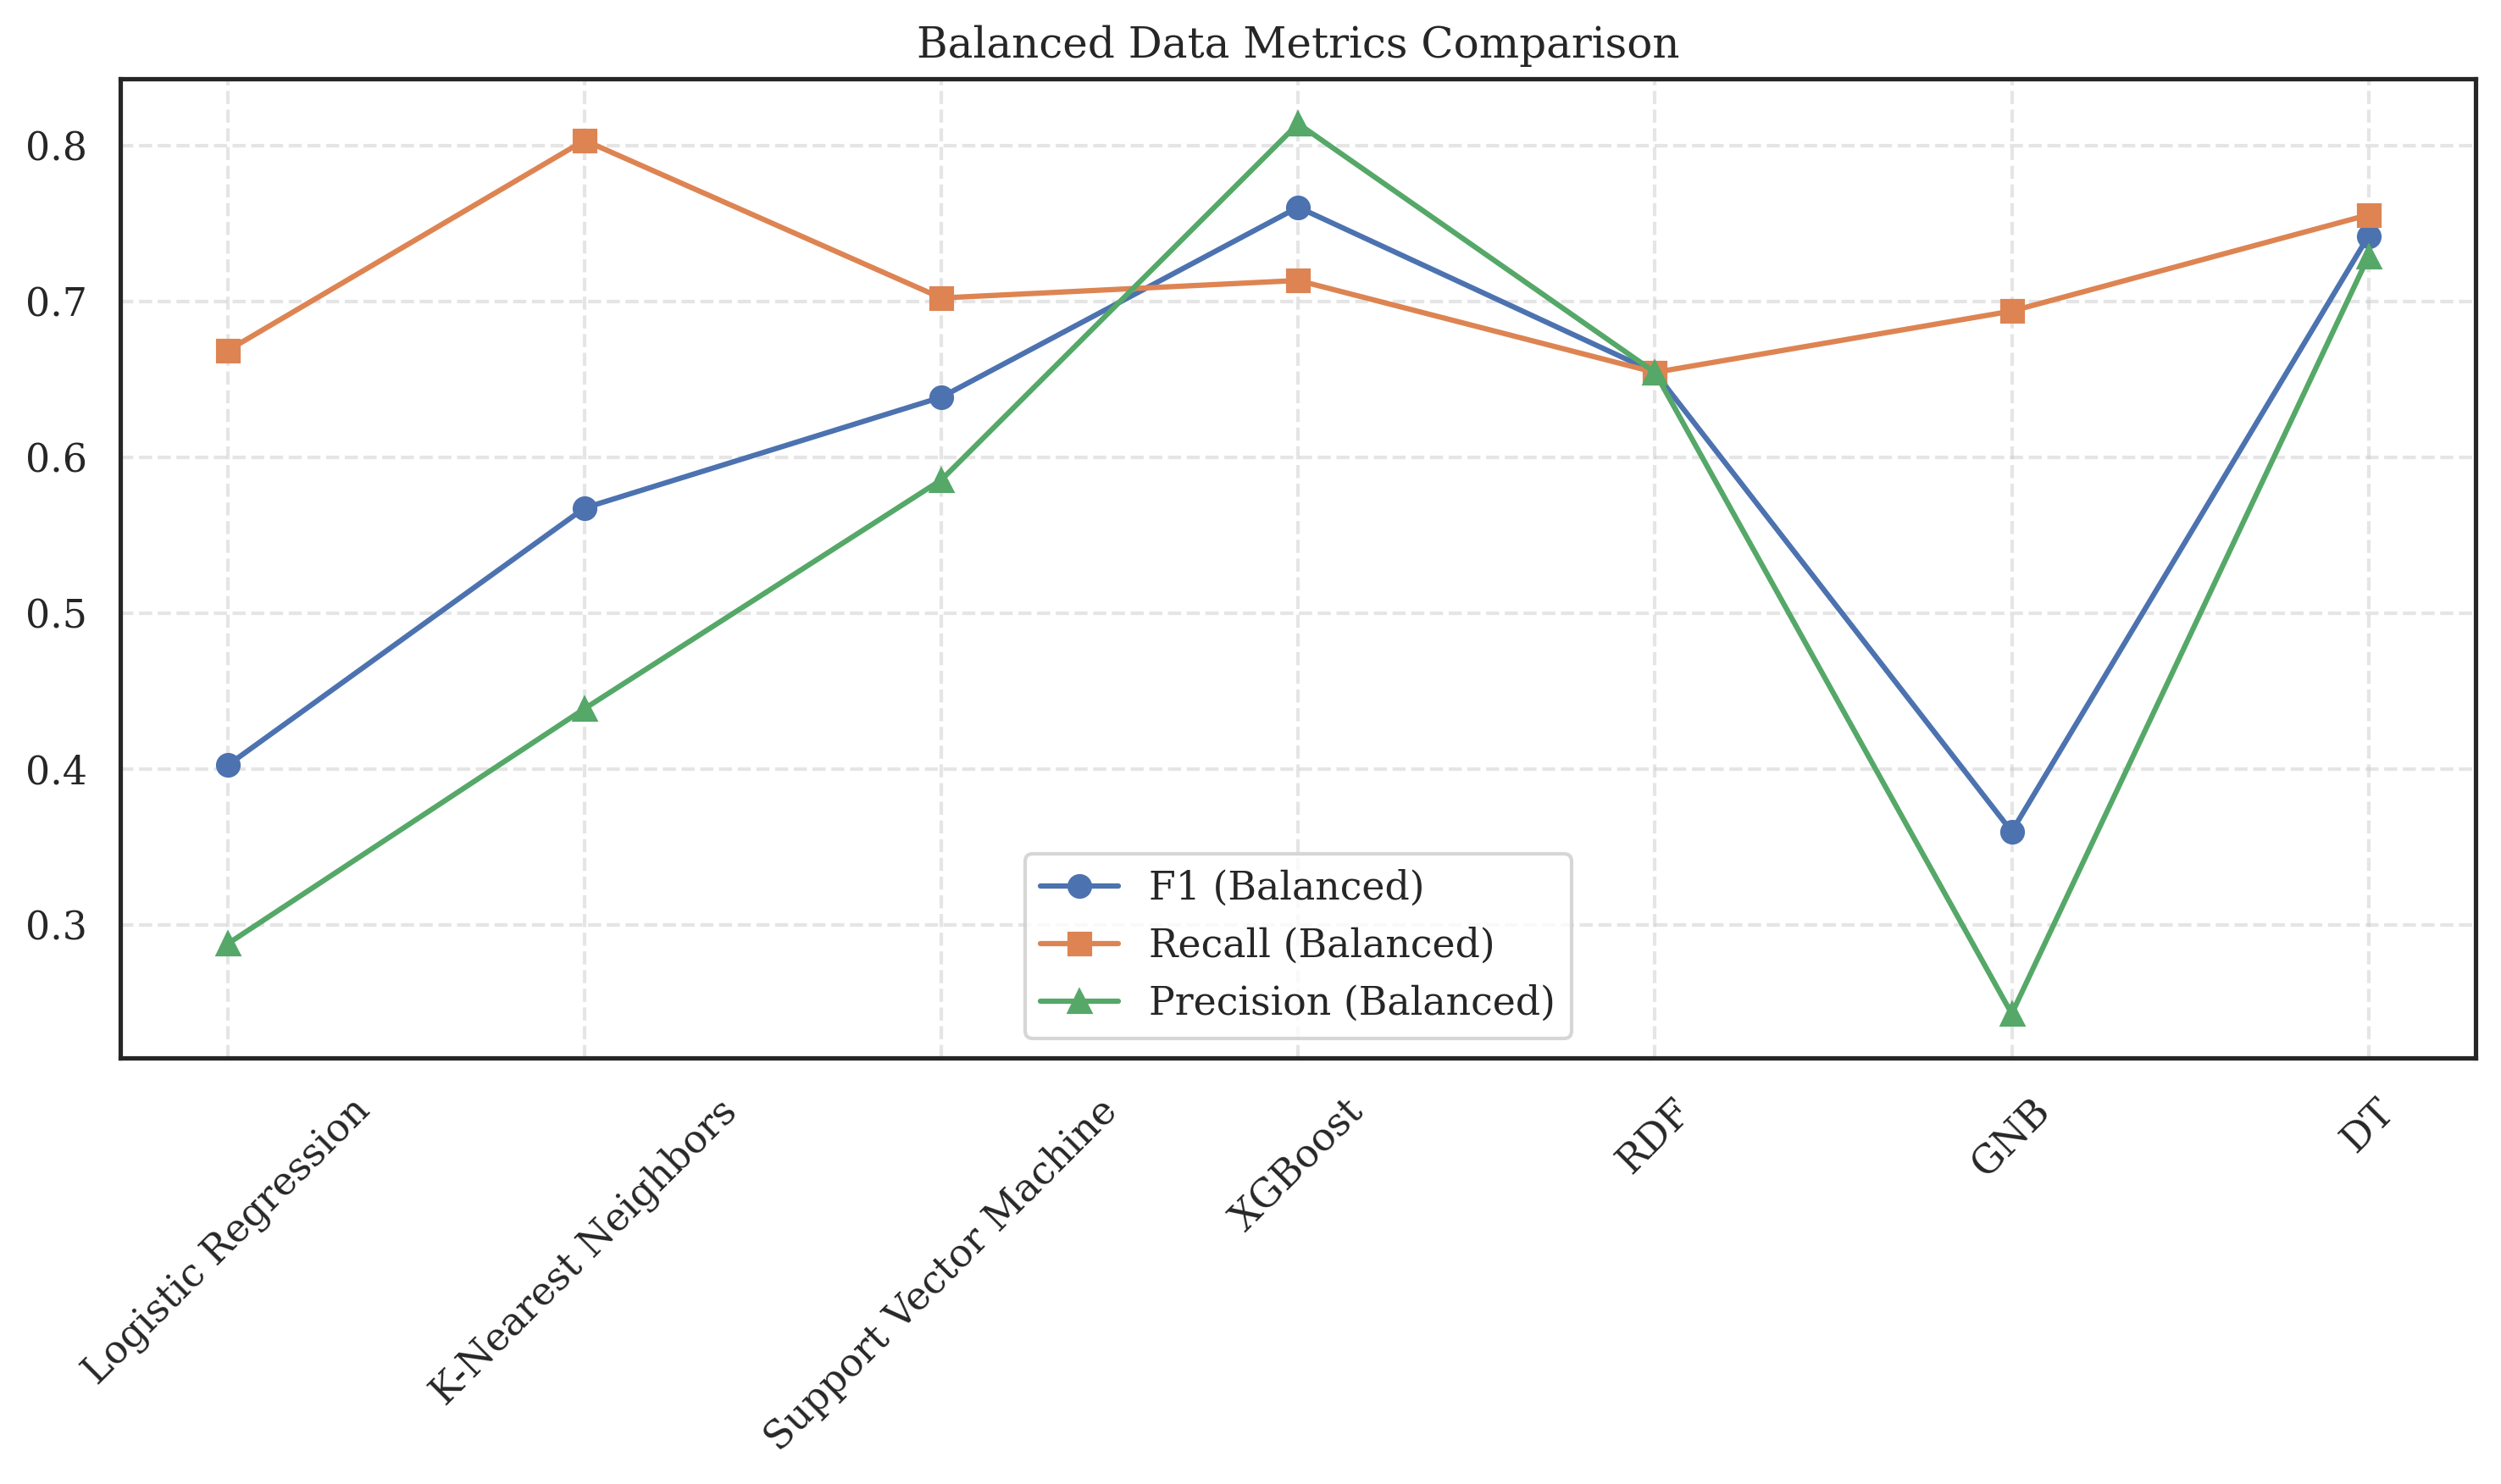

In [90]:
plt.figure(figsize=(10,6), dpi=300)

plt.plot(models, df_balanced["F1"], marker='o', label="F1 (Balanced)")
plt.plot(models, df_balanced["Recall"], marker='s', label="Recall (Balanced)")
plt.plot(models, df_balanced["Precision"], marker='^', label="Precision (Balanced)")

plt.xticks(rotation=45)
plt.title("Balanced Data Metrics Comparison")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("multi_balanced.png", dpi=300)
plt.show()